# Tumoroid polygon annotation

Steps:
1. **Imports**: import libraries, load data
2. **Global view**: overview map to locate the tumoroids
3. **Save**: load existing polygons (JSON)
4. **Annotation**: interactive annotation (ginput, one per tumoroid)
5. **Visualization**: check that tumoroids were correctly outlined

## Imports and global view:
1. **Imports:**  
This cell loads all the necessary libraries and builds the AnnData object from the expression matrix and the H&E image.
`shapely` is used to manipulate polygons, `cmath` for angular sorting of points.
The scalefactor retrieved here converts spot coordinates to pixel coordinates in the image.

In [11]:
import sys, os, json, cmath
sys.path.append('/home/lili/Documents/M1/S2/stage/the_during/phase1/scripts')
from CreateSquidpyBMKObject import create_s1000_object
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
from scipy import stats


matrix_path = '/home/lili/Documents/M1/S2/stage/the_during/phase1/scripts/level_1/level_1'
png_path    = '/home/lili/Documents/M1/S2/stage/the_during/phase1/scripts/level_1/pics/he_roi_small.png'

adata = create_s1000_object(
    matrix_path, png_path,
    spot_radius=1, min_cells=5, min_features=40, resolution='spot'
)

scalef    = adata.uns['spatial']['sample1']['scalefactors']['tissue_hires_scalef']
he_image  = adata.uns['spatial']['sample1']['images']['hires']
coords    = adata.obsm['spatial']
n_genes   = adata.obs['n_genes'].values

JSON_PATH = 'polygones_tumoroids.json'

# approximate centres and radii for reference (spot coordinates)
TUMOROIDS = {
    'T1': (235, 400, 32),
    'T2': (392, 350, 45),
    'T3': (465, 380, 38),
    'T4': (412, 475, 38),
    'T5': (465, 507, 34),
    'T6': (277, 577, 48),
    'T7': (285, 653, 27),
    'T8': (560, 610, 42),
    'T9': (800, 660, 48),
}

def sort_by_angle(points):
    """Sort clicked points by angle from the centroid to avoid self-intersections."""
    cx = sum(p[0] for p in points) / len(points)
    cy = sum(p[1] for p in points) / len(points)
    return sorted(points, key=lambda p: cmath.phase(complex(p[0] - cx, p[1] - cy)))

print('Data loaded.')
print(f'  {adata.n_obs} spots, {adata.n_vars} genes')
print(f'  scalefactor = {scalef:.4f}')

Data loaded.
  167598 spots, 26283 genes
  scalefactor = 1.0232


2. **Global view:**  
We display an overview of all tumoroids on the image. The circles are rough approximations placed manually as a visual guide for annotation, they are not precise outlines.

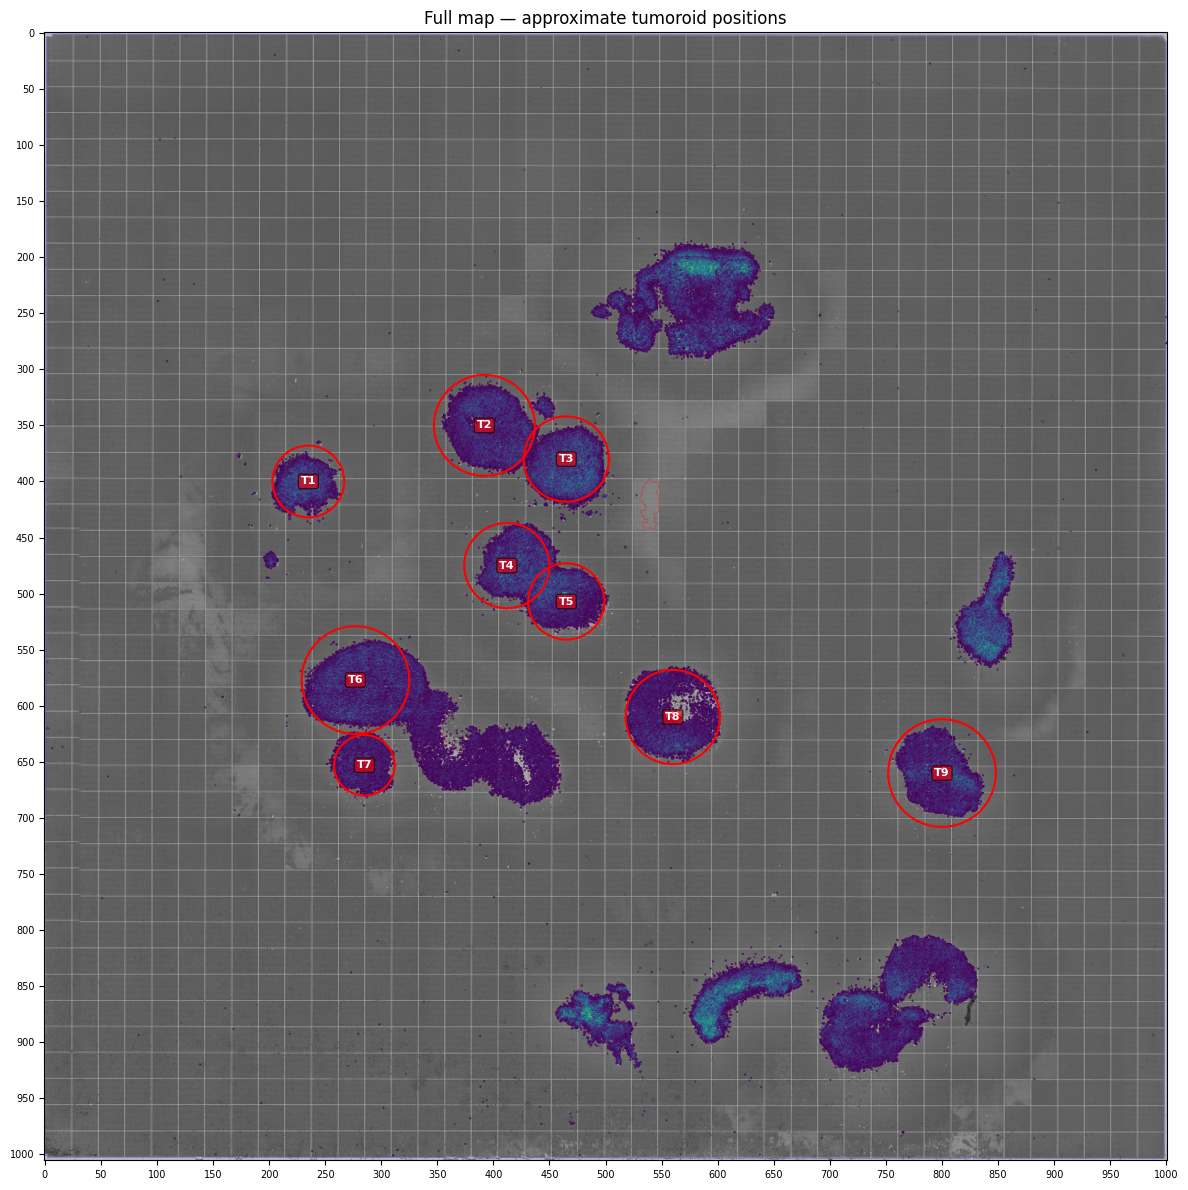

In [12]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(he_image, cmap='gray')
ax.scatter(coords[:, 0] * scalef, coords[:, 1] * scalef,
           c=n_genes, s=0.3, cmap='viridis', alpha=0.8)

for label, (cx, cy, r) in TUMOROIDS.items():
    circle = plt.Circle((cx * scalef, cy * scalef), r * scalef,
                         fill=False, edgecolor='red', linewidth=1.5)
    ax.add_patch(circle)
    ax.text(cx * scalef, cy * scalef, label,
            color='white', fontsize=8, fontweight='bold',
            ha='center', va='center',
            bbox=dict(facecolor='red', alpha=0.6, boxstyle='round,pad=0.2'))

step = 50
ticks_x = np.arange(0, he_image.shape[1], step * scalef)
ticks_y = np.arange(0, he_image.shape[0], step * scalef)
ax.set_xticks(ticks_x)
ax.set_xticklabels([f'{int(t/scalef)}' for t in ticks_x], fontsize=7)
ax.set_yticks(ticks_y)
ax.set_yticklabels([f'{int(t/scalef)}' for t in ticks_y], fontsize=7)
ax.set_title('Full map — approximate tumoroid positions')
plt.tight_layout()
plt.savefig('carte_tumoroids_numerotes.png', dpi=150, bbox_inches='tight')
plt.show()

3. **Save:**  
Polygons are saved incrementally to a JSON file so we don't have to redo everything on each notebook restart. This cell loads whatever has already been annotated.

In [13]:
# Load existing polygons
if os.path.exists(JSON_PATH):
    with open(JSON_PATH) as f:
        polygons_data = json.load(f)
    print(f'Polygons loaded: {list(polygons_data.keys())}')
    remaining = [t for t in TUMOROIDS if t not in polygons_data]
    if remaining:
        print(f'To annotate: {remaining}')
    else:
        print('All tumoroids annotated.')
else:
    polygons_data = {}
    print('No polygons yet. To annotate: T1, T2, T3, T4, T5, T6, T7')

Polygons loaded: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
All tumoroids annotated.


## Tumoroid annotation:
4. **Annotation:**  
When we change the tumoroid name at the top, and run the cell, a window opens with the image zoomed in on that tumoroid. We click the outline manually around the cell area, then press Enter to finish. The dashed yellow circle is a reference guide. If a polygon already exists for this tumoroid, it shows in red so we can correct it if needed.

In [18]:
%matplotlib tk

TUMOROID_TO_ANNOTATE = 'T9'   # Tumoroid name

cx, cy, r = TUMOROIDS[TUMOROID_TO_ANNOTATE]
margin = r + 25

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(he_image, cmap='gray')
ax.scatter(coords[:, 0] * scalef, coords[:, 1] * scalef,
           c=n_genes, s=0.5, cmap='viridis', alpha=0.8)

# reference circle
circle = plt.Circle((cx * scalef, cy * scalef), r * scalef,
                     fill=False, edgecolor='yellow', linewidth=1.5, linestyle='--')
ax.add_patch(circle)

# existing polygon if already annotated
if TUMOROID_TO_ANNOTATE in polygons_data:
    poly_ex = Polygon(polygons_data[TUMOROID_TO_ANNOTATE])
    x_p, y_p = poly_ex.exterior.xy
    ax.plot(np.array(x_p) * scalef, np.array(y_p) * scalef,
            'r-', linewidth=2, label='existing polygon')
    ax.legend(fontsize=8)

ax.set_xlim((cx - margin) * scalef, (cx + margin) * scalef)
ax.set_ylim((cy + margin) * scalef, (cy - margin) * scalef)
ax.set_title(f'{TUMOROID_TO_ANNOTATE} — click the outline, press Enter to finish')
plt.tight_layout()
plt.show()

points_px = plt.ginput(n=-1, timeout=0)
print(f'{len(points_px)} points recorded')

29 points recorded


The pixel coordinates of the clicked points are converted to spot coordinates (divided by the scalefactor), then sorted by angle from the centroid using `cmath.phase`. This sorting avoids polygon self-intersections (without it, segments cross and the shape becomes inconsistent). The result is saved to the JSON.

In [19]:
# Convert pixels -> spot coords, sort by angle, save
if len(points_px) < 3:
    print('Not enough points, try again.')
else:
    points_spot = [(px / scalef, py / scalef) for px, py in points_px]
    points_spot = sort_by_angle(points_spot)

    polygons_data[TUMOROID_TO_ANNOTATE] = points_spot

    with open(JSON_PATH, 'w') as f:
        json.dump(polygons_data, f, indent=2)

    print(f'{TUMOROID_TO_ANNOTATE} saved ({len(points_spot)} points).')
    print(f'Available polygons: {list(polygons_data.keys())}')
    print(f'Remaining: {[t for t in TUMOROIDS if t not in polygons_data]}')

T9 saved (29 points).
Available polygons: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
Remaining: []


**Visual polygon check**  

After each annotation, we visually verify that the polygon correctly outlines the right tumoroid. Selected spots appear in light blue.

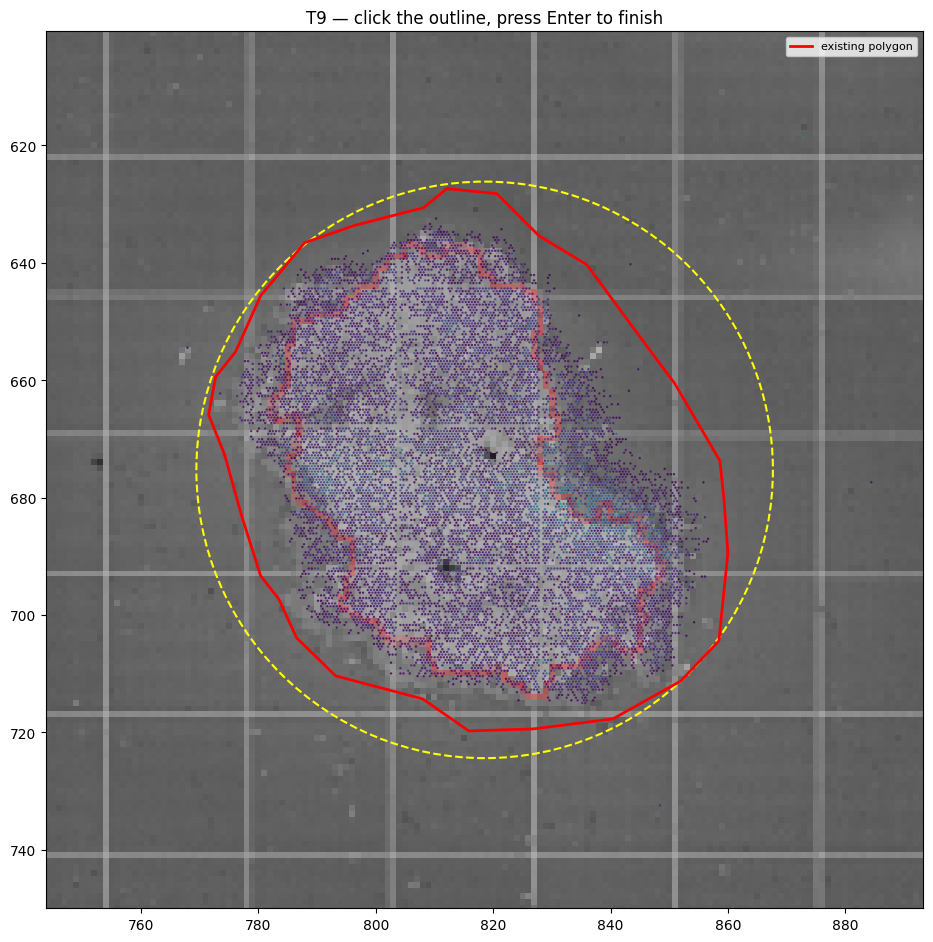

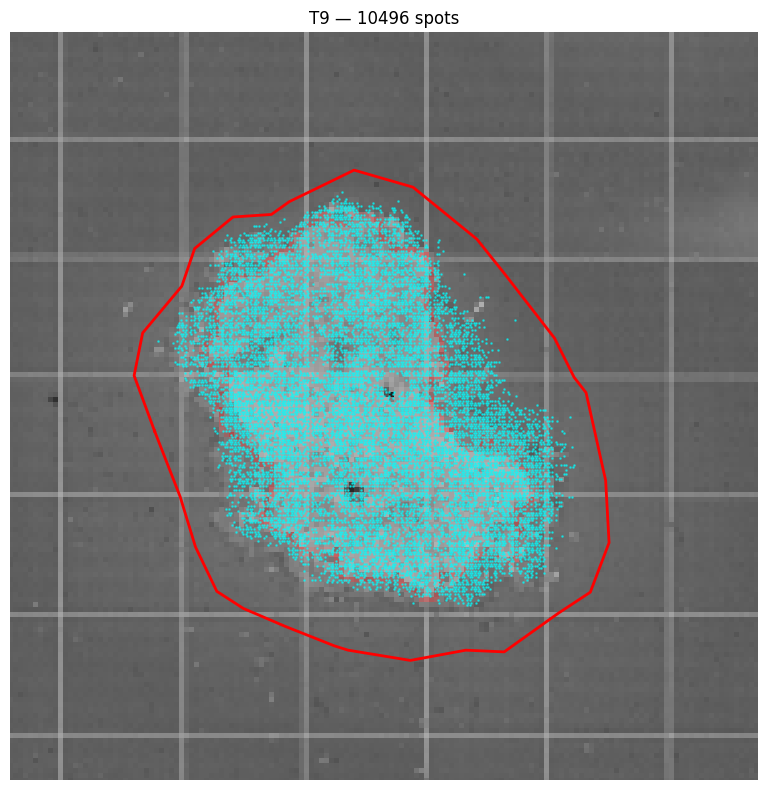

In [20]:
%matplotlib inline

TUMOROID_TO_CHECK = TUMOROID_TO_ANNOTATE  # or change manually

if TUMOROID_TO_CHECK not in polygons_data:
    print(f'{TUMOROID_TO_CHECK} not annotated yet.')
else:
    cx, cy, r = TUMOROIDS[TUMOROID_TO_CHECK]
    margin = r + 25
    poly = Polygon(polygons_data[TUMOROID_TO_CHECK])

    mask = np.array([poly.contains(Point(x, y)) for x, y in coords])
    coords_t = coords[mask]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(he_image, cmap='gray')
    ax.scatter(coords_t[:, 0] * scalef, coords_t[:, 1] * scalef,
               s=0.8, c='cyan', alpha=0.6)

    x_p, y_p = poly.exterior.xy
    ax.plot(np.array(x_p) * scalef, np.array(y_p) * scalef,
            color='red', linewidth=2)

    ax.set_xlim((cx - margin) * scalef, (cx + margin) * scalef)
    ax.set_ylim((cy + margin) * scalef, (cy - margin) * scalef)
    ax.set_title(f'{TUMOROID_TO_CHECK} — {mask.sum()} spots')
    ax.axis('off')
    plt.tight_layout()
    plt.show()